# 04 — Active clients by country and town

Active clients (`role_id = 6`, `is_active = 1`, `soft_delete = 0`) grouped by `country` and `town`, ordered by count descending. Mirrors `docs/Client_Querires.md` §1.1.

In [ ]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
SELECT country, town, COUNT(*) AS active_clients
FROM users
WHERE role_id = 6
  AND is_active = 1
  AND soft_delete = 0
GROUP BY country, town
ORDER BY active_clients DESC;
"""

df = pd.read_sql(query, engine)
print(df)

    country           town  active_clients
0        UK         London              15
1        US    Los Angeles               6
2        RO           iasi               6
3        GR         Athens               6
4        UK      Liverpool               5
5        SE      Stockholm               4
6        IE         Dublin               4
7        FR          Paris               4
8        TR       Istanbul               4
9        ES         Madrid               4
10       BG          Sofia               3
11       ES      Barcelona               2
12       RO      Bucharest               2
13  Italian           iasi               2
14       IT        Bologna               2
15       US        Detroit               2
16       RO          Bacau               1
17       RO         berlin               1
18       US         Newark               1
19       IT           roma               1
20       JM       Kingston               1
21      USA          miami               1
22       US

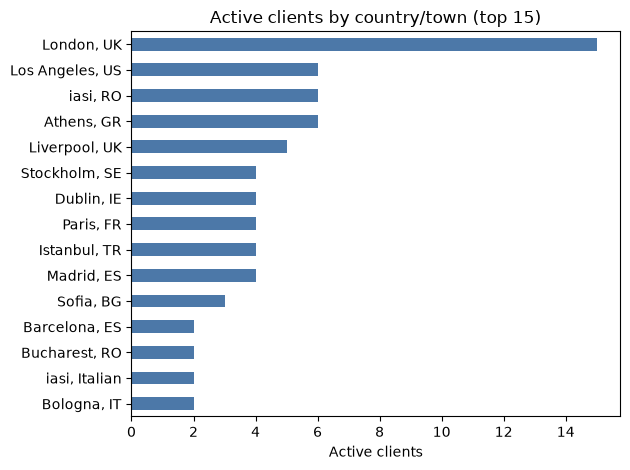

In [3]:
%matplotlib inline
import os
import matplotlib.pyplot as plt

top = df.head(15).assign(label=lambda d: d["town"] + ", " + d["country"])
top.plot(kind="barh", x="label", y="active_clients", legend=False, color="#4C78A8")
plt.gca().invert_yaxis()
plt.title("Active clients by country/town (top 15)")
plt.xlabel("Active clients")
plt.ylabel("")
plt.tight_layout()

os.makedirs("../assets/img", exist_ok=True)
plt.savefig("../assets/img/active_clients_by_country_town.png", dpi=150)
plt.show()